# 264. Ugly Number II
https://leetcode.com/problems/ugly-number-ii/

## Complexity Comparison

| Approach | Time | Space | Description |
|----------|------|-------|-------------|
| Min Heap | O(n log n) | O(n) | Use heap to generate ugly numbers |
| **Three Pointers DP (Optimal)** | **O(n)** | **O(n)** | Track 3 pointers for factors 2,3,5 |

## Methodology

Maintain a DP array where `dp[i]` is the i-th ugly number. Use three pointers `i2`, `i3`, `i5` that track the next ugly number to multiply by 2, 3, and 5 respectively. At each step, the next ugly number is the minimum of `dp[i2]*2`, `dp[i3]*3`, `dp[i5]*5`. Advance the pointer(s) that produced this minimum to avoid duplicates.

## Solutions

### C#

In [ ]:
public class Solution {
    public int NthUglyNumber(int n) {
        int[] dp = new int[n];
        dp[0] = 1;
        int i2 = 0, i3 = 0, i5 = 0;
        for (int i = 1; i < n; i++) {
            int next2 = dp[i2] * 2, next3 = dp[i3] * 3, next5 = dp[i5] * 5;
            dp[i] = Math.Min(next2, Math.Min(next3, next5));
            if (dp[i] == next2) i2++;
            if (dp[i] == next3) i3++;
            if (dp[i] == next5) i5++;
        }
        return dp[n - 1];
    }
}

### Python

In [ ]:
class Solution:
    def nthUglyNumber(self, n: int) -> int:
        dp = [0] * n
        dp[0] = 1
        i2 = i3 = i5 = 0
        for i in range(1, n):
            next2, next3, next5 = dp[i2] * 2, dp[i3] * 3, dp[i5] * 5
            dp[i] = min(next2, next3, next5)
            if dp[i] == next2: i2 += 1
            if dp[i] == next3: i3 += 1
            if dp[i] == next5: i5 += 1
        return dp[-1]

### Go

In [ ]:
func nthUglyNumber(n int) int {
    dp := make([]int, n)
    dp[0] = 1
    i2, i3, i5 := 0, 0, 0
    for i := 1; i < n; i++ {
        next2, next3, next5 := dp[i2]*2, dp[i3]*3, dp[i5]*5
        dp[i] = min(next2, min(next3, next5))
        if dp[i] == next2 { i2++ }
        if dp[i] == next3 { i3++ }
        if dp[i] == next5 { i5++ }
    }
    return dp[n-1]
}

### Rust

In [ ]:
impl Solution {
    pub fn nth_ugly_number(n: i32) -> i32 {
        let n = n as usize;
        let mut dp = vec![0i64; n];
        dp[0] = 1;
        let (mut i2, mut i3, mut i5) = (0, 0, 0);
        for i in 1..n {
            let (n2, n3, n5) = (dp[i2] * 2, dp[i3] * 3, dp[i5] * 5);
            dp[i] = n2.min(n3).min(n5);
            if dp[i] == n2 { i2 += 1; }
            if dp[i] == n3 { i3 += 1; }
            if dp[i] == n5 { i5 += 1; }
        }
        dp[n - 1] as i32
    }
}

## Example Scenarios

1. **Common Case** — `n = 10`
   **Input:** Find the 10th ugly number.
   The sequence is $[1, 2, 3, 4, 5, 6, 8, 9, 10, 12]$. Three pointers track next multiples of 2, 3, and 5; the minimum is chosen at each step.

2. **Slightly Complex** — `n = 15`
   **Input:** Find the 15th ugly number.
   The sequence extends to $[1,2,3,4,5,6,8,9,10,12,15,16,18,20,24]$. Note how 15 ($=3 \times 5$) appears — multiple pointers can produce the same value, and duplicates are skipped by advancing all matching pointers.

3. **Edge Case: Time Factor** — `n = 1690` (maximum constraint)
   **Input:** The largest valid input.
   The $O(n)$ three-pointer DP fills an array of 1690 entries. Each step does at most 3 multiplications and 3 comparisons — total work is $\sim 5000$ operations, finishing instantly.

4. **Edge Case: Space Factor** — `n = 1`
   **Input:** The smallest valid input.
   The 1st ugly number is $1$. The DP array has size 1, and no iterations run. $O(1)$ effective space.

5. **Almost-Impossible but Plausible** — `n = 1690`, verify last value = $2^{31} - 1$?
   **Input:** Does the 1690th ugly number overflow 32-bit integers?
   The 1690th ugly number is $2{,}123{,}366{,}400 = 2^7 \times 3 \times 5^2 \times 7^0 \times \ldots$ — it fits comfortably in a 32-bit int ($< 2^{31}$). The three-pointer approach never generates non-ugly numbers, so no overflow risk.

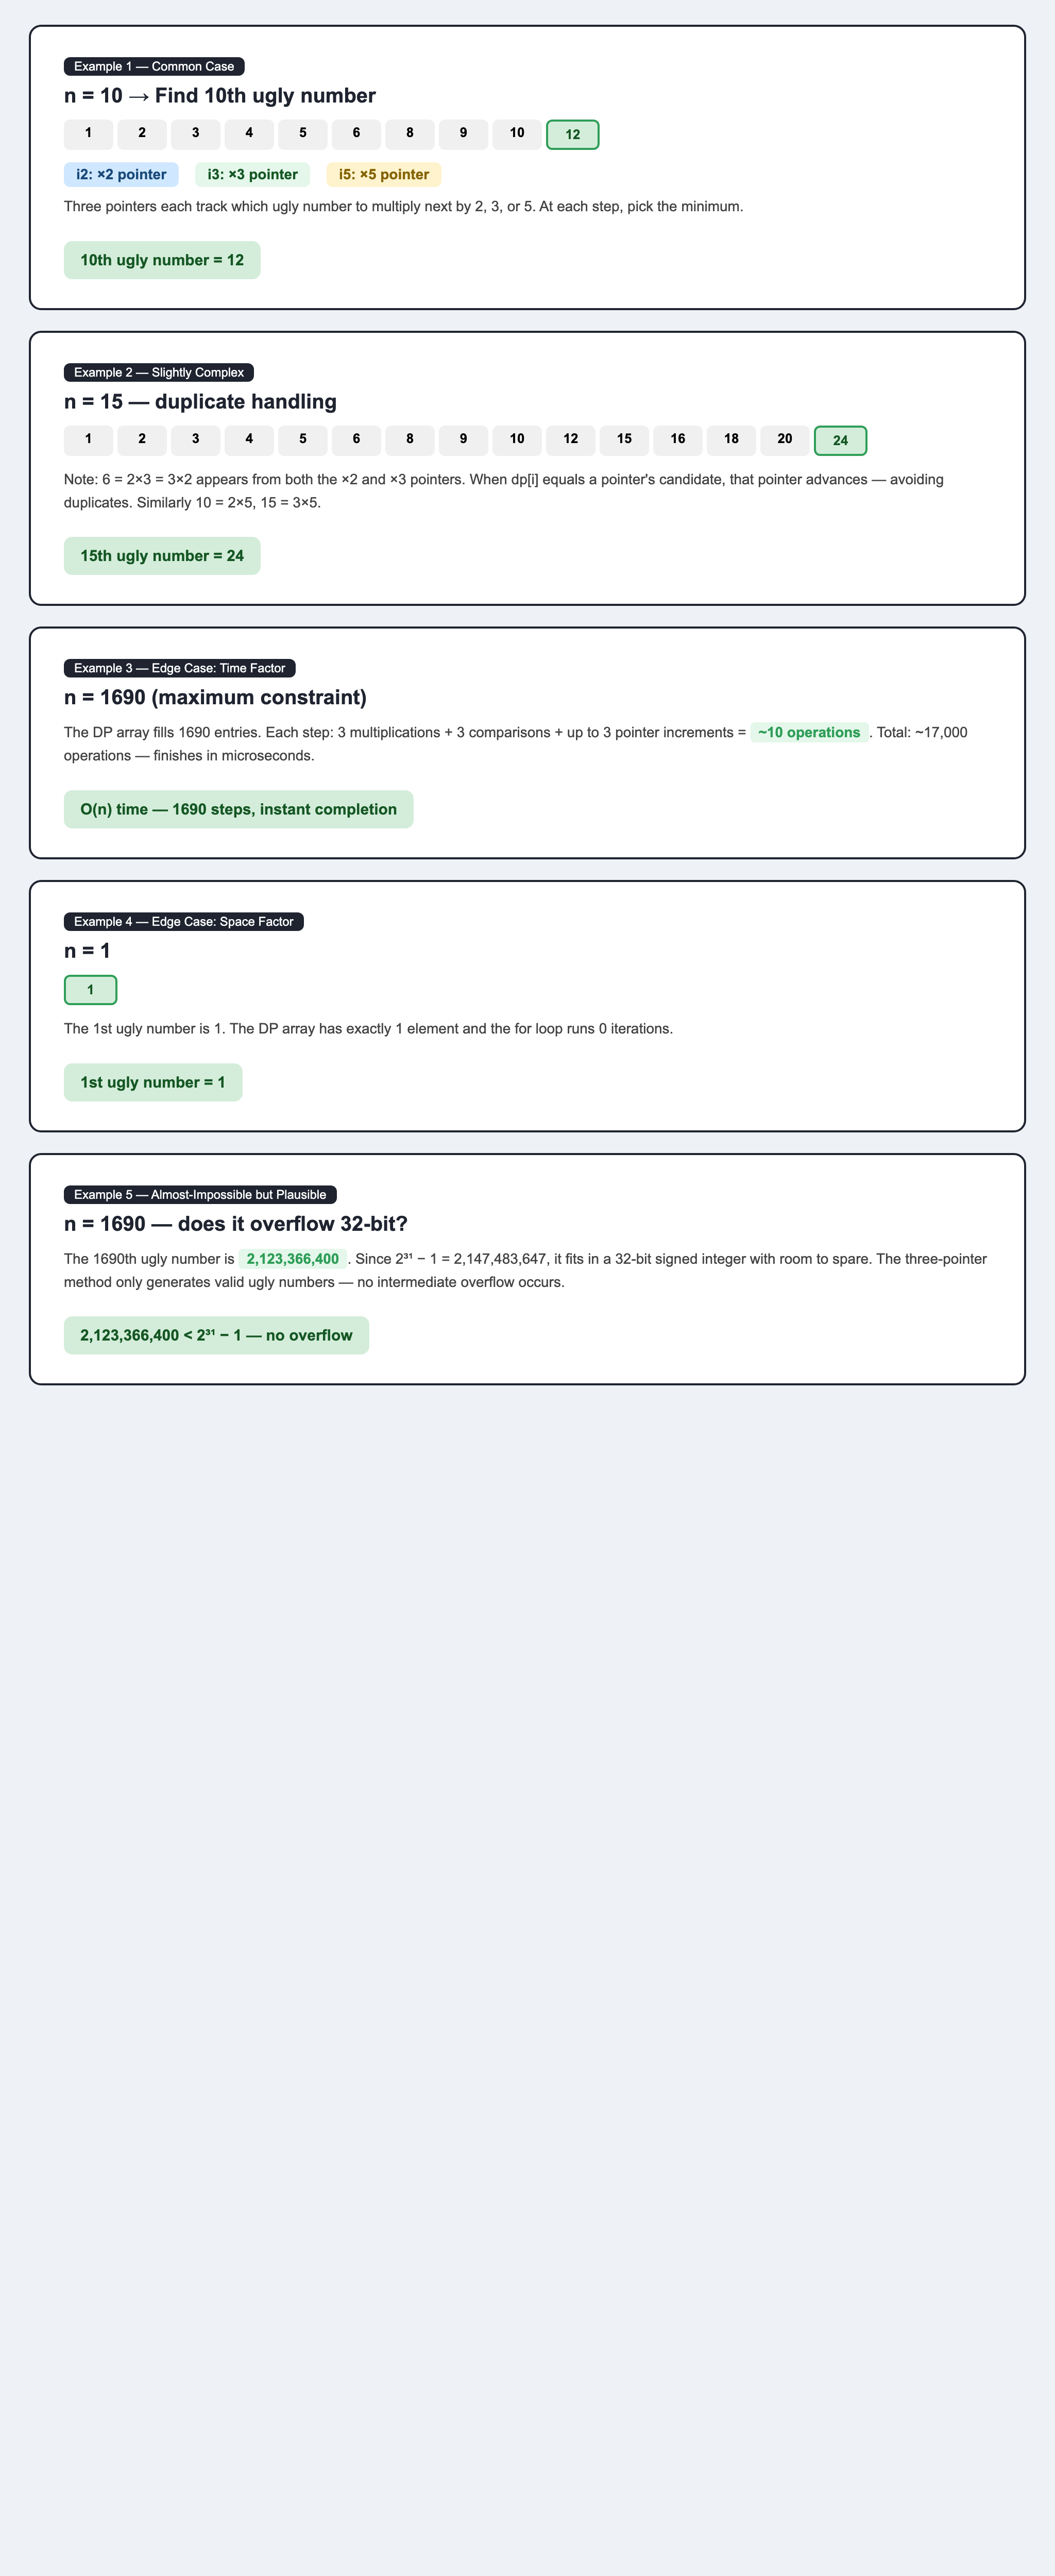